In [246]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from tslearn.metrics import cdist_dtw
from helper_plots import plot_pseudotime_for_cells

def sample_rows_per_cluster(df, cluster_col, n=5, random_state=42):
    return (
        df
        .groupby(cluster_col, group_keys=False)
        .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))
    )


def compute_mean_std(ts_list):
    ts_list = [np.asarray(ts, dtype=float) for ts in ts_list]
    max_len = max(len(ts) for ts in ts_list)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), constant_values=np.nan)
        for ts in ts_list
    ]
    mat = np.vstack(aligned)
    return np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)

def plot_kmeans_mean_shapes(X, labels):
    plt.figure(figsize=(12,6))

    for lab in sorted(set(labels)):
        idx = np.where(labels == lab)[0]
        ts_list = [X[i] for i in idx]

        mean_ts, std_ts = compute_mean_std(ts_list)
        t = np.arange(len(mean_ts))

        plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)
        plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.2)

    plt.title("KMeans Mean Shape per Cluster (± STD)")
    plt.legend()
    plt.show()

In [247]:

SD_clean = pd.read_pickle("datasets/pseudotime_cells_clean.pkl")

n = 6  # minimum required length

SD_clean = SD_clean[SD_clean["pseudotime_widths"].apply(len) >= n]

X = SD_clean["pseudotime_widths"].to_list()

SD_clean

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,centered_bbox_min_x,centered_bbox_min_y,centered_bbox_max_x,centered_bbox_max_y,bbox_rot_min_x,bbox_rot_min_y,bbox_rot_max_x,bbox_rot_max_y,pseudotime,pseudotime_widths
obj_id,,,,,,,,,,,,,,,,,,,,,
10001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.320611,8.603053,0.293314,...,-36.5,-47.5,-7.5,-28.5,-54.673970,-38.246371,-20.130348,-7.757043,"[11, 12, 13, 14, 15, 16, 0, 0, 1, 2, 3, 4, 5, ...","[8, 7, 5, 5, 7, 14, 24, 22, 16, 13, 9, 9, 7, 7..."
20001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.272553,5.027085,0.366094,...,-33.5,-44.5,-19.5,-28.5,-50.609410,-29.909405,-30.692043,-9.181178,"[13, 14, 15, 16, 0, 0, 1, 2, 3, 4, 5]","[5, 5, 7, 14, 24, 22, 16, 13, 9, 9, 7]"
30001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.171021,5.244656,0.419590,...,-50.5,43.5,-29.5,74.5,-23.797167,52.290145,9.401867,89.543473,"[9, 10, 11, 12, 13, 14, 15, 16, 0, 0, 1, 2, 3,...","[9, 9, 8, 8, 7, 6, 9, 19, 25, 22, 17, 12, 11, ..."
40001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.165913,4.848332,0.433454,...,-48.5,62.5,-25.5,81.5,-13.017359,67.113982,16.245415,94.755039,"[14, 15, 16, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, ...","[6, 9, 19, 25, 22, 17, 12, 11, 9, 9, 7, 7, 9, ..."
50001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.519174,12.748607,0.539141,...,31.5,-11.5,52.5,4.5,22.265263,-35.043998,48.343620,-10.992788,"[15, 16, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[8, 14, 23, 22, 16, 14, 10, 9, 8, 7, 6, 7, 8, 9]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7240001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.306034,11.760468,0.419473,...,-21.5,-1.5,8.5,17.5,-19.635105,-5.355263,15.788658,25.608777,"[10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3, 4, 5,...","[8, 7, 6, 6, 7, 12, 23, 24, 17, 15, 11, 10, 9,..."
7250001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.031863,0.800109,0.474371,...,-31.5,-6.5,-8.5,9.5,-30.810077,-1.685867,-2.971438,23.314766,"[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0,...","[8, 7, 7, 9, 9, 8, 7, 6, 6, 7, 12, 23, 24, 17,..."
7260001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.064615,1.787692,0.812035,...,20.5,-17.5,46.5,5.5,9.735438,-37.476574,43.537484,-4.890816,"[8, 9, 10, 11, 12, 13, 14, 15, 16, 0, 0, 1, 2,...","[7, 9, 8, 8, 8, 6, 5, 8, 14, 23, 22, 

In [248]:
from sklearn.cluster import KMeans


features = [
    [
        np.mean(ts),
        np.std(ts),
        # np.max(ts),
        # np.min(ts),
        len(ts)
    ]
    for ts in X
]

# #ignore class 3(grenn)
kmeans = KMeans(n_clusters=3, random_state=42)
# kmeans.fit(features)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=3)
X_embedded = pca.fit_transform(X_scaled)

kmeans.fit(X_embedded)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


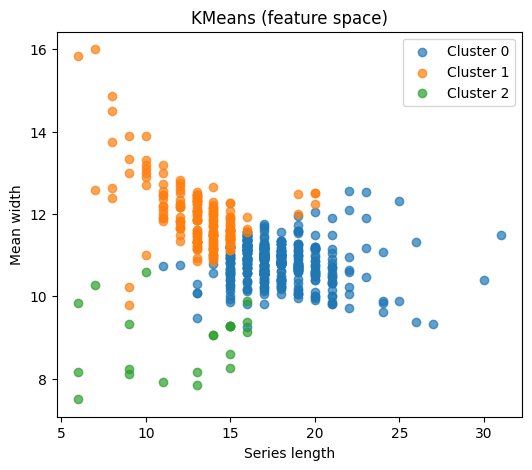

In [249]:
labels_kmeans = kmeans.labels_

features = np.array(features)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(
        features[idx, -1],     # length
        features[idx, 0],      # mean
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel("Series length")
plt.ylabel("Mean width")
plt.title("KMeans (feature space)")
plt.legend()
plt.show()

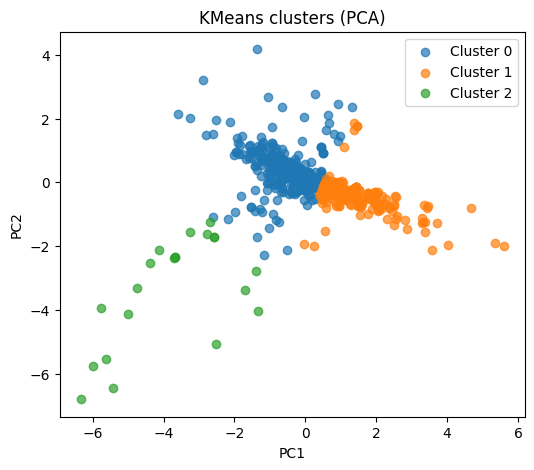

In [250]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(features)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (PCA)")
plt.legend()
plt.show()

C:\Users\dmitr\AppData\Local\Temp\ipykernel_17024\1466150877.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))


C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj590001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj2330001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5220001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj4690001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3250001_stainDAPI.tif


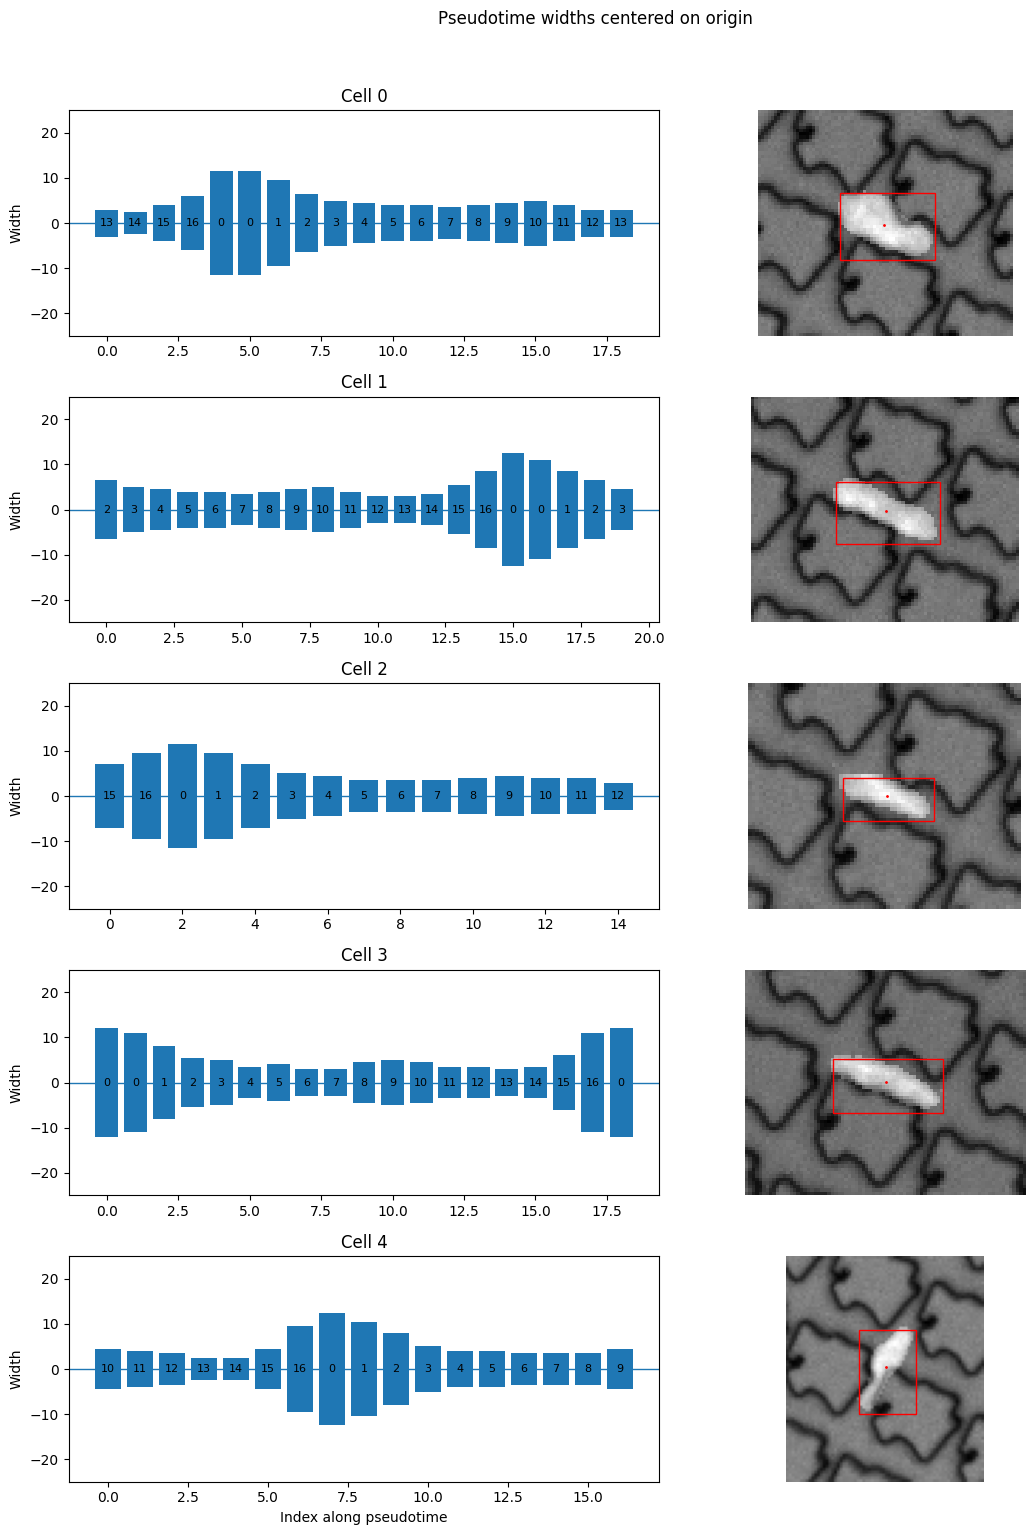

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj530001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj4500001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj950001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3680001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5670001_stainDAPI.tif


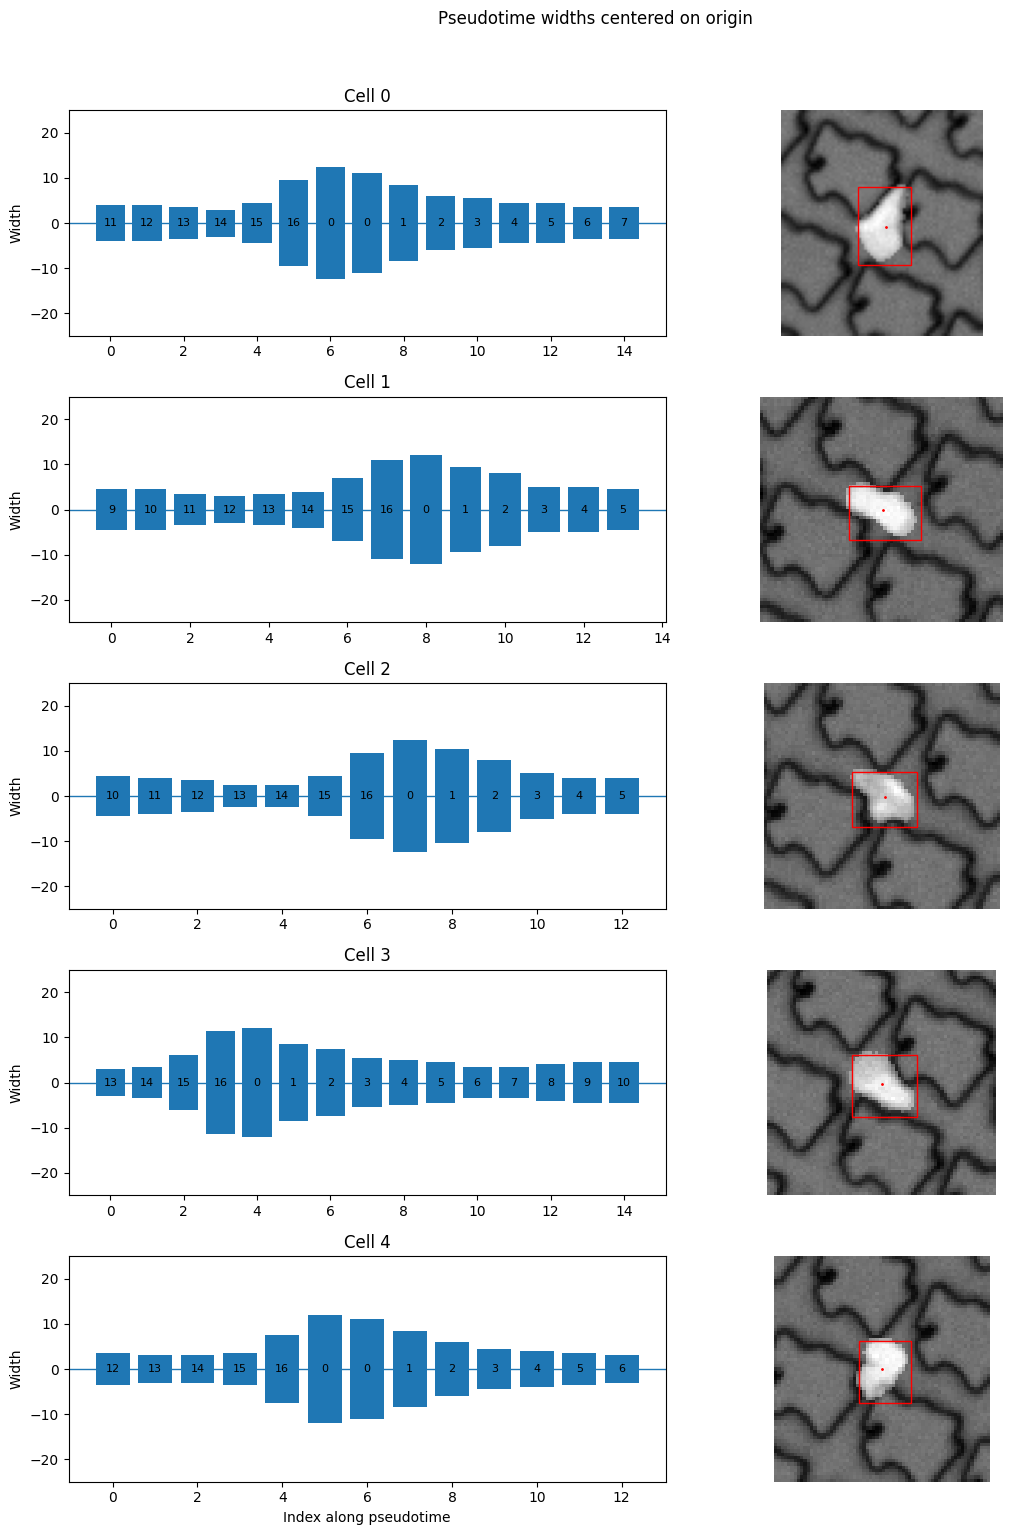

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj6070002_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3390001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5420001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj160001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj170001_stainDAPI.tif


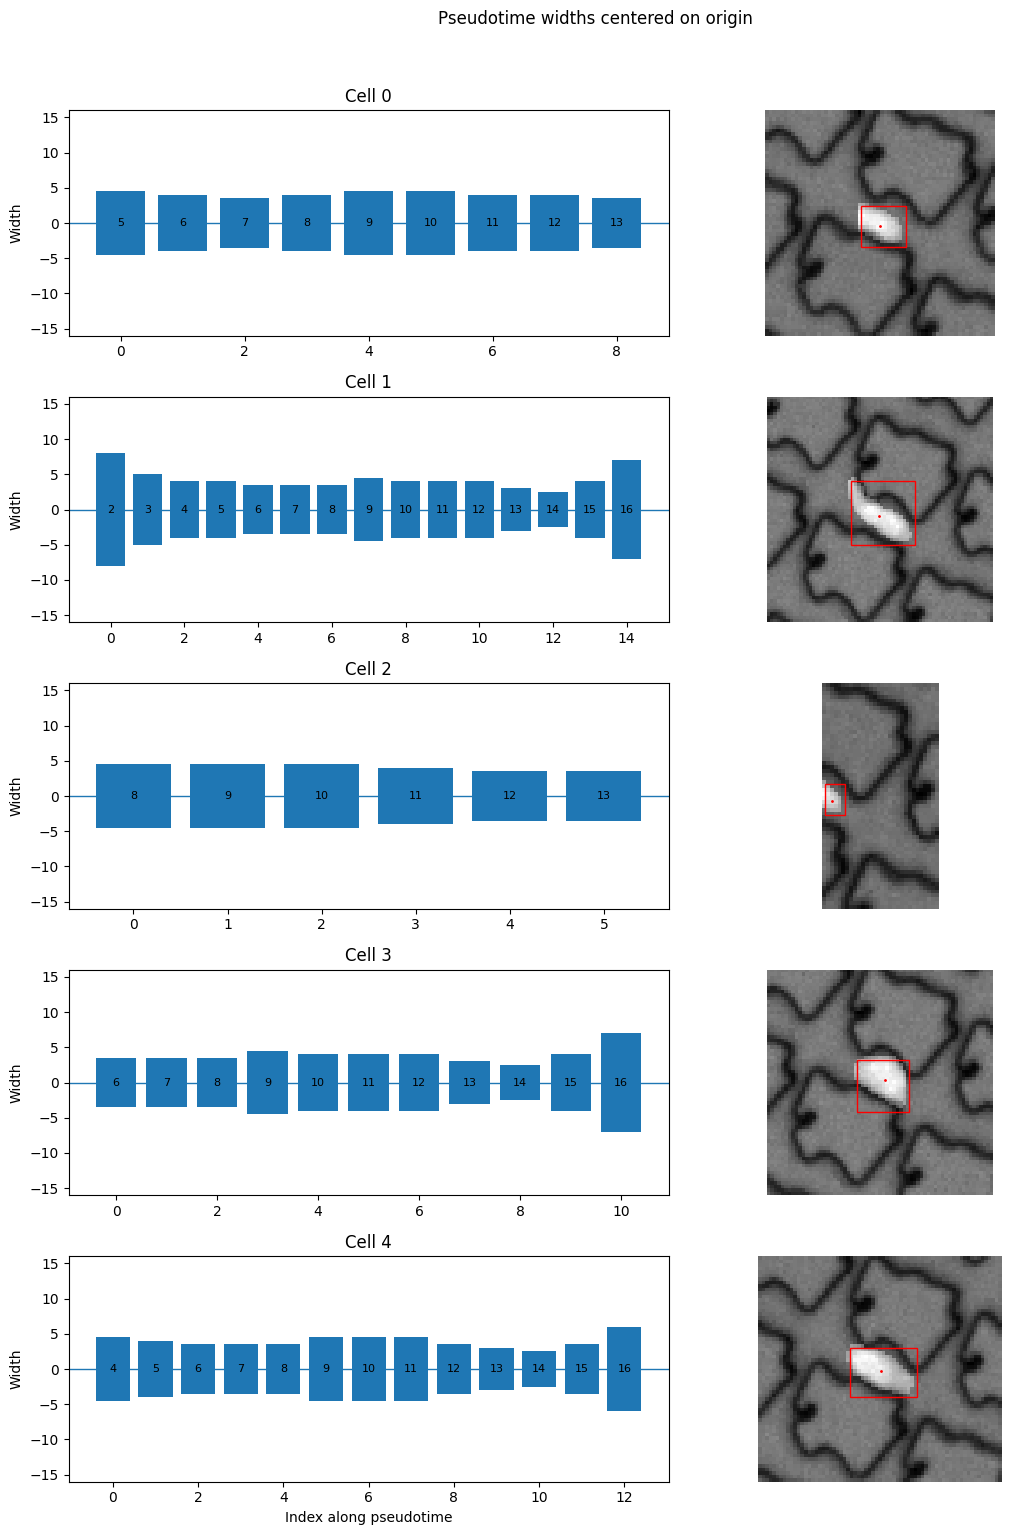

In [251]:
SD_clean['cluster_kmeans'] = labels_kmeans

df_kmeans_samples = sample_rows_per_cluster(
    SD_clean,
    cluster_col='cluster_kmeans',
    n=5
)

df_kmeans_samples

plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 0'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 1'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 2'), num_cells=5)

<Axes: xlabel='cluster_kmeans'>

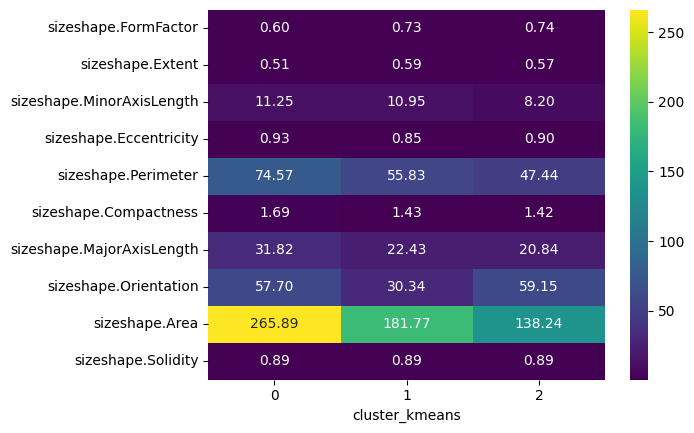

In [271]:
import seaborn as sns

feats = ['AreaShape_FormFactor', 'AreaShape_Extent','AreaShape_MinorAxisLength',
         'AreaShape_Eccentricity',  'AreaShape_Perimeter', 'AreaShape_Compactness', 
         'AreaShape_MajorAxisLength', 'AreaShape_Orientation',
         'AreaShape_Area','AreaShape_Solidity',
        ]

def name_in_df(feat):
    return  'sizeshape.' + feat.split('_')[1]

feats_CPmeasure = []
for feat in feats:
    col = name_in_df(feat)
    if col in SD_clean.columns:
        feats_CPmeasure.append(col)
    else:
        print(f"Feature {name_in_df(feat)} not found in dataframe")


SD_clean[feats_CPmeasure + ['cluster_kmeans']].groupby('cluster_kmeans').mean()

sns.heatmap( SD_clean[feats_CPmeasure + ['cluster_kmeans']] .groupby('cluster_kmeans') .mean() .T, cmap="viridis", annot=True, fmt=".2f" )

<Axes: xlabel='cluster_kmeans'>

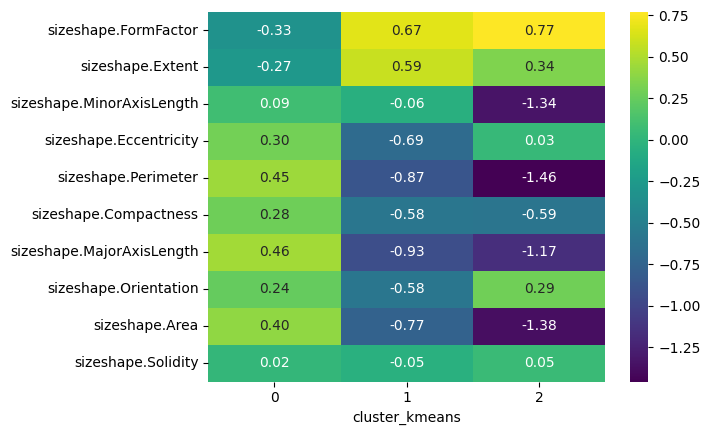

In [253]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean[feats_CPmeasure])

SD_scaled = SD_clean.copy()
SD_scaled[feats_CPmeasure] = scaled



sns.heatmap(
    SD_scaled[feats_CPmeasure + ['cluster_kmeans']]
    .groupby('cluster_kmeans')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

#Is cluster 3 an outlier cluster with very small cells?

0 0.4671940747767123
1 0.3504117914641998
2 0.3727560532160477


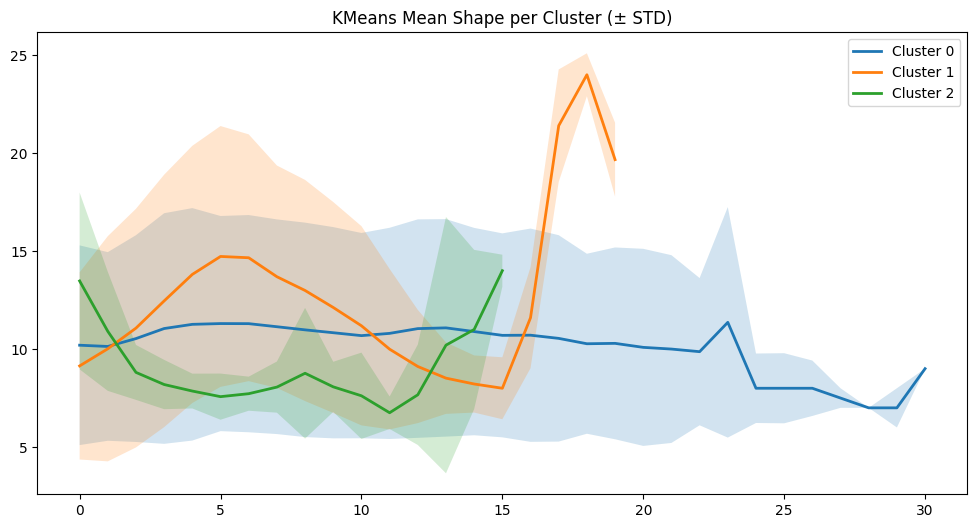

In [254]:
from sklearn.metrics import silhouette_samples

s = silhouette_samples(X_scaled, labels_kmeans)
for k in np.unique(labels_kmeans):
    print(k, s[labels_kmeans == k].mean())

X_kmeans = SD_clean["pseudotime_widths"].to_list()
labels_kmeans = SD_clean["cluster_kmeans"].values

plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)

In [255]:
mask = labels_kmeans != 2
features_no_outliers = features[mask]
X_scaled_no_Outliers = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=2, random_state=42)
labels_clean = kmeans.fit_predict(X_scaled_no_Outliers)
    
s_clean = silhouette_samples(X_scaled_no_Outliers, labels_clean)

for k in np.unique(labels_clean):
    print(k, s_clean[labels_clean == k].mean())


0 0.3701896845542917
1 0.37842550621022264


<Axes: xlabel='cluster_kmeans_no_outliers'>

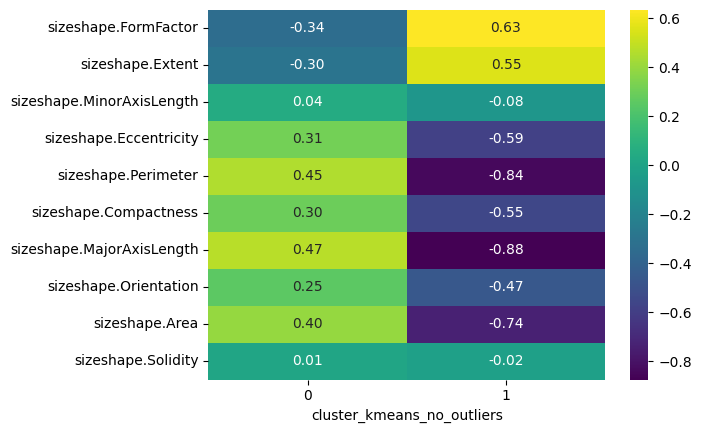

In [256]:
SD_clean_no_outliers = SD_clean.copy()
SD_clean_no_outliers['cluster_kmeans_no_outliers'] = np.where(mask, labels_clean, -1)
SD_clean_no_outliers = SD_clean_no_outliers[SD_clean_no_outliers['cluster_kmeans_no_outliers'] != -1]

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean_no_outliers[feats_CPmeasure])

SD_clean_no_outliers[feats_CPmeasure] = scaled

sns.heatmap(
    SD_clean_no_outliers[feats_CPmeasure + ['cluster_kmeans_no_outliers']]
    .groupby('cluster_kmeans_no_outliers')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

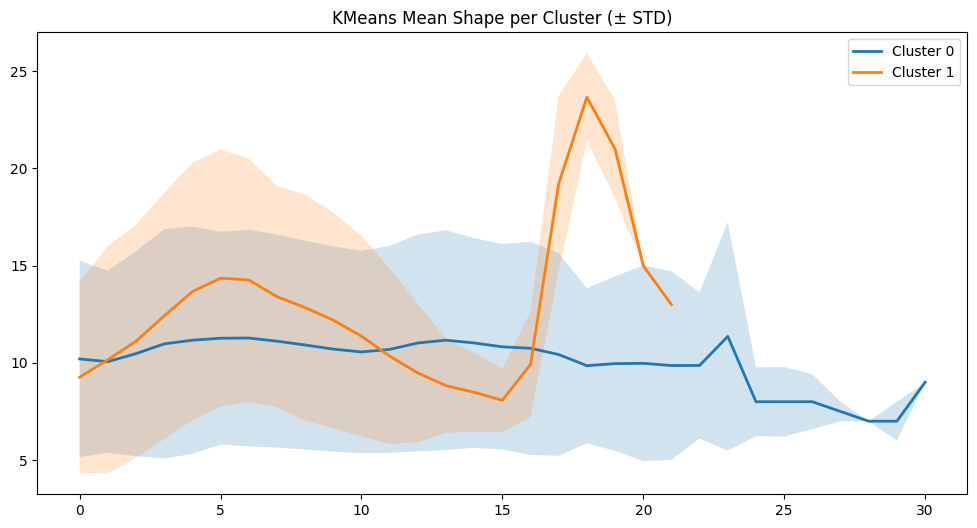

In [257]:
X_kmeans = SD_clean_no_outliers["pseudotime_widths"].to_list()
labels_kmeans = SD_clean_no_outliers["cluster_kmeans_no_outliers"].values



plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)

In [258]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# 1) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 2) Optional: PCA to remove collinearity/noise
pca = PCA(n_components=2)  # or more components if needed
X_pca = pca.fit_transform(X_scaled)

# 3) Fit GMM
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
gmm.fit(X_pca)

# 4) Cluster labels (hard assignment)
labels_gmm = gmm.predict(X_pca)

# 5) Membership probabilities (soft assignment)
probs = gmm.predict_proba(X_pca)   # shape: (n_samples, 3)

# 6) Evaluate quality
sil = silhouette_score(X_pca, labels_gmm)
print("Silhouette GMM:", sil)

Silhouette GMM: 0.4078810661482521


In [259]:
import hdbscan

X = SD_clean['pseudotime_widths'].to_list()

X = [ts for ts in X if len(ts) >= n]  # filter out short series

X = [(ts - np.mean(ts)) / np.std(ts) for ts in X] # z-score normalization

D_dtw = cdist_dtw(X)


In [260]:
import umap
lengths = np.array([len(ts) for ts in X])
L = np.abs(lengths[:, None] - lengths[None, :])

alpha = 0.3  # controls importance of length
D = D_dtw + alpha * L

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean'
)

mapper = umap.UMAP(
    metric="precomputed",
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = mapper.fit_transform(D_dtw)

labels_hdb = clusterer.fit_predict(X_umap)  # -1 = noise

unique, counts = np.unique(labels_hdb, return_counts=True)
print(dict(zip(unique, counts)))

c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{np.int64(-1): np.int64(4), np.int64(0): np.int64(33), np.int64(1): np.int64(65), np.int64(2): np.int64(156), np.int64(3): np.int64(292), np.int64(4): np.int64(58), np.int64(5): np.int64(72)}


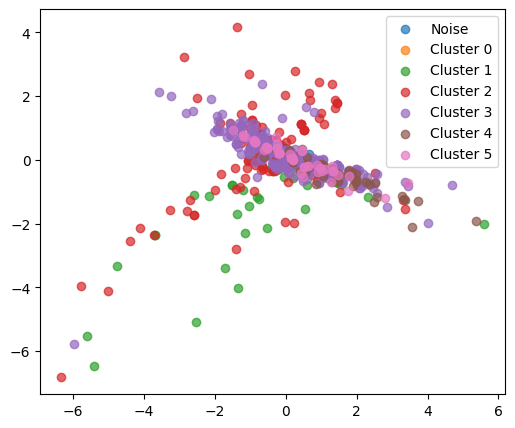

In [261]:
plt.figure(figsize=(6,5))
for c in np.unique(labels_hdb):
    idx = labels_hdb == c
    label = "Noise" if c == -1 else f"Cluster {c}"
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.7)
plt.legend()
plt.show()

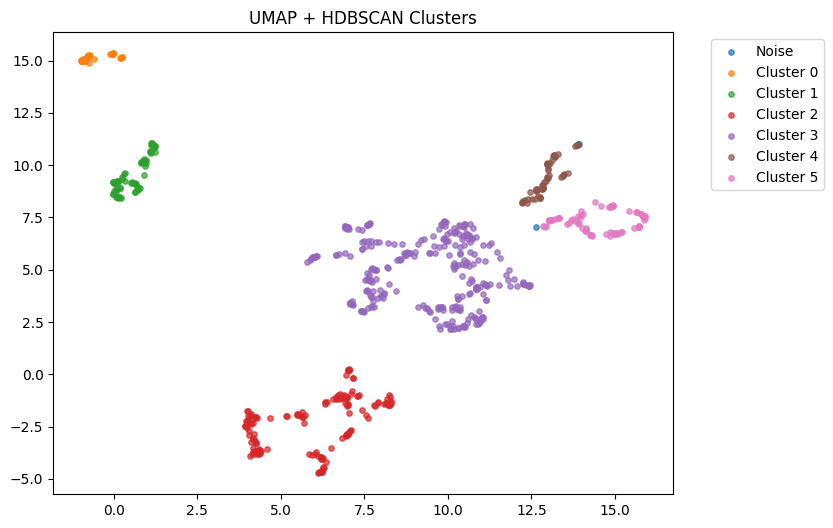

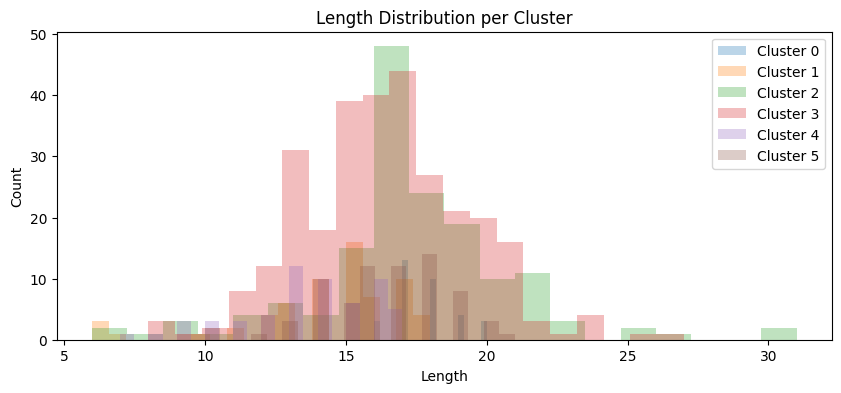

In [262]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
unique_labels = np.unique(labels_hdb)

for lab in unique_labels:
    idx = labels_hdb == lab
    label = "Noise" if lab == -1 else f"Cluster {lab}"
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], s=15, alpha=0.7, label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("UMAP + HDBSCAN Clusters")
plt.show()

def plot_length_distribution(X, labels):
    lengths = np.array([len(ts) for ts in X])

    plt.figure(figsize=(10,4))
    for lab in sorted(set(labels)):
        if lab == -1:
            continue
        idx = labels == lab
        plt.hist(lengths[idx], bins=20, alpha=0.3, label=f"Cluster {lab}")

    plt.legend()
    plt.title("Length Distribution per Cluster")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.show()

plot_length_distribution(X, labels_hdb)

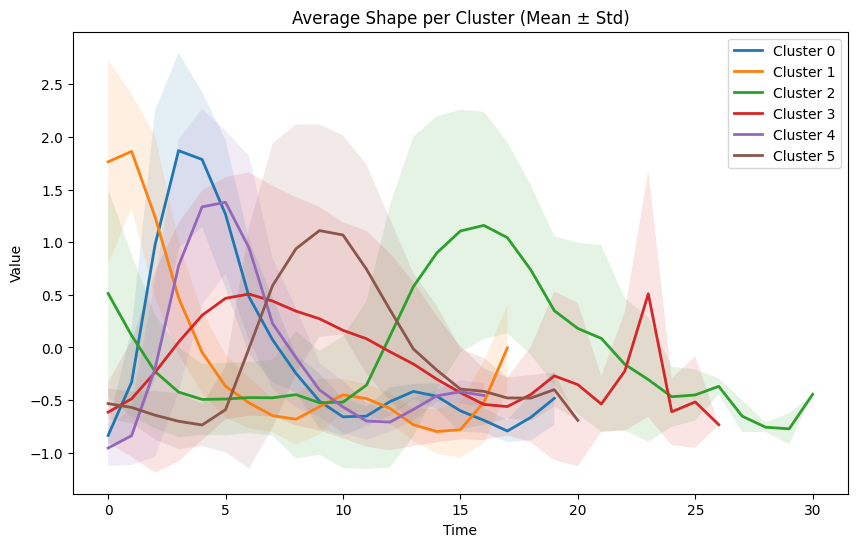

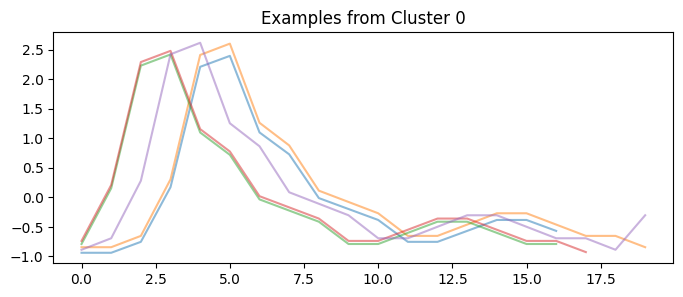

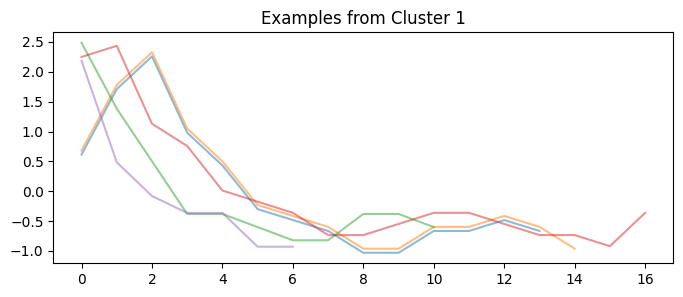

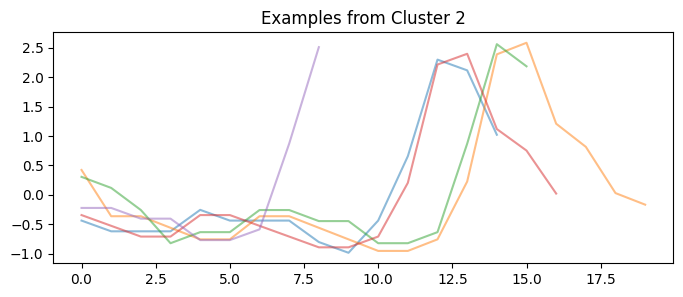

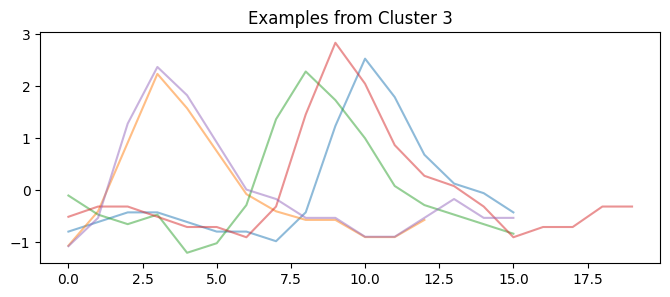

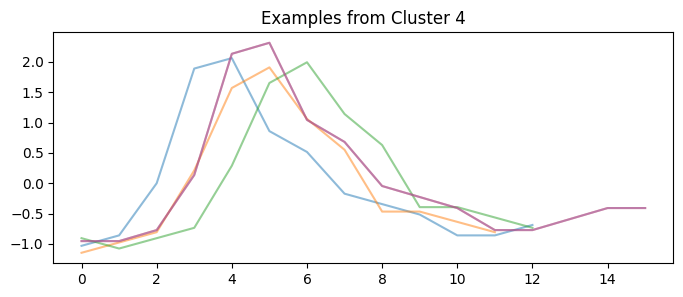

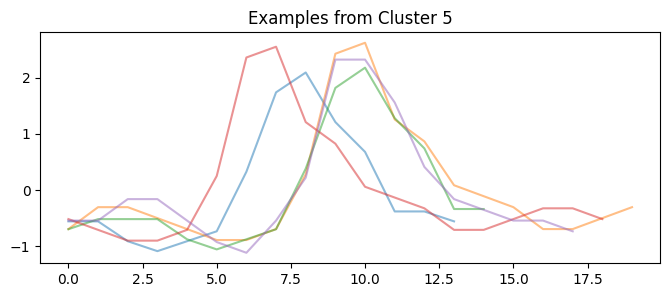

In [263]:
plt.figure(figsize=(10, 6))

for lab in np.unique(labels_hdb):
    if lab == -1:
        continue

    idx = labels_hdb == lab
    cluster_ts = [np.asarray(X[i], dtype=float) for i in np.where(idx)[0]]

    # Pad all sequences to the max length
    max_len = max(len(ts) for ts in cluster_ts)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), 'constant', constant_values=np.nan)
        for ts in cluster_ts
    ]
    aligned = np.vstack(aligned)

    # Mean and STD
    mean_ts = np.nanmean(aligned, axis=0)
    std_ts  = np.nanstd(aligned, axis=0)

    t = np.arange(max_len)

    # Plot mean
    plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)

    # Plot STD as shaded area
    plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.12)

plt.legend()
plt.title("Average Shape per Cluster (Mean ± Std)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

import random

for lab in np.unique(labels_hdb):
    if lab == -1:
        continue
    
    idx = np.where(labels_hdb == lab)[0]
    sample_idxs = random.sample(list(idx), min(5, len(idx)))

    plt.figure(figsize=(8, 3))
    for i in sample_idxs:
        plt.plot(X[i], alpha=0.5)
    plt.title(f"Examples from Cluster {lab}")
    plt.show()

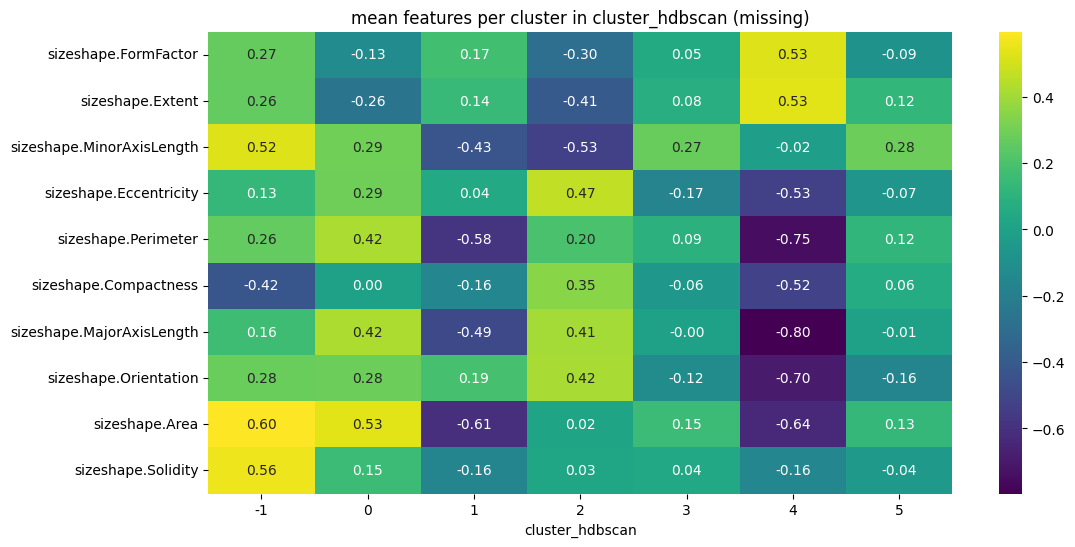

In [285]:
SD_scaled["cluster_hdbscan"] = labels_hdb

def plot_metadata_heatmap(df, features, cluster_col, title="missing"):
    plt.figure(figsize=(12,6))
    sns.heatmap(
        df[features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T,
        cmap="viridis",
        annot=True,
        fmt=".2f",
    )
    plt.title(f"mean features per cluster in {cluster_col} ({title})")
    plt.show()




plot_metadata_heatmap(
    SD_scaled,
    feats_CPmeasure,                # your list of metadata/morphology features
    "cluster_hdbscan"
)

In [275]:
SD_scaled
SD_scaled["ImageNumber"] = SD_scaled.index // 10000
SD_scaled["ObjectNumber"] = SD_scaled.index % 10000
px = SD_scaled[SD_scaled["ImageNumber"] == 7][["ObjectNumber", "sizeshape.Center_X", "sizeshape.Center_Y"]]
px

,ObjectNumber,sizeshape.Center_X,sizeshape.Center_Y
obj_id,,,
70001,1,81.699571,87.592275
70002,2,83.668016,207.186235


In [242]:
import os
import shutil
from tqdm import tqdm

def export_dapi_by_cluster(df, cluster_col, dapi_col, out_dir):
    """
    df          : pandas DataFrame
    cluster_col : column name containing cluster labels (e.g. 'cluster_hdbscan')
    dapi_col    : column name containing the DAPI file paths (e.g. 'path_dapi')
    out_dir     : output directory where cluster folders will be created
    """

    os.makedirs(out_dir, exist_ok=True)

    for cluster in sorted(df[cluster_col].unique()):
        cluster_path = os.path.join(out_dir, f"cluster_{cluster}")
        os.makedirs(cluster_path, exist_ok=True)

        sub_df = df[df[cluster_col] == cluster]

        print(f"Exporting {len(sub_df)} DAPI images for cluster {cluster}...")

        for _, row in tqdm(sub_df.iterrows(), total=len(sub_df)):
            src = row[dapi_col]
            
            if not os.path.exists(src):
                print(f"WARNING: File not found: {src}")
                continue

            # keep original filename
            filename = os.path.basename(src)
            dst = os.path.join(cluster_path, filename)

            shutil.copy(src, dst)

    print("Done.")

export_dapi_by_cluster(
    df=SD_scaled,                # your dataframe
    cluster_col="cluster_hdbscan",   # or cluster_kmeans_no_outliers
    dapi_col="path_dapi",
    out_dir="sorted_dapi_images_UMAP+HDBSCAN"     # will be created automatically
)

Exporting 4 DAPI images for cluster -1...


100%|██████████| 4/4 [00:00<00:00, 666.11it/s]


Exporting 33 DAPI images for cluster 0...


100%|██████████| 33/33 [00:00<00:00, 941.99it/s]


Exporting 65 DAPI images for cluster 1...


100%|██████████| 65/65 [00:00<00:00, 729.68it/s]


Exporting 156 DAPI images for cluster 2...


100%|██████████| 156/156 [00:00<00:00, 714.95it/s]


Exporting 292 DAPI images for cluster 3...


100%|██████████| 292/292 [00:00<00:00, 845.61it/s]


Exporting 58 DAPI images for cluster 4...


100%|██████████| 58/58 [00:00<00:00, 891.50it/s]


Exporting 72 DAPI images for cluster 5...


100%|██████████| 72/72 [00:00<00:00, 985.41it/s]

Done.


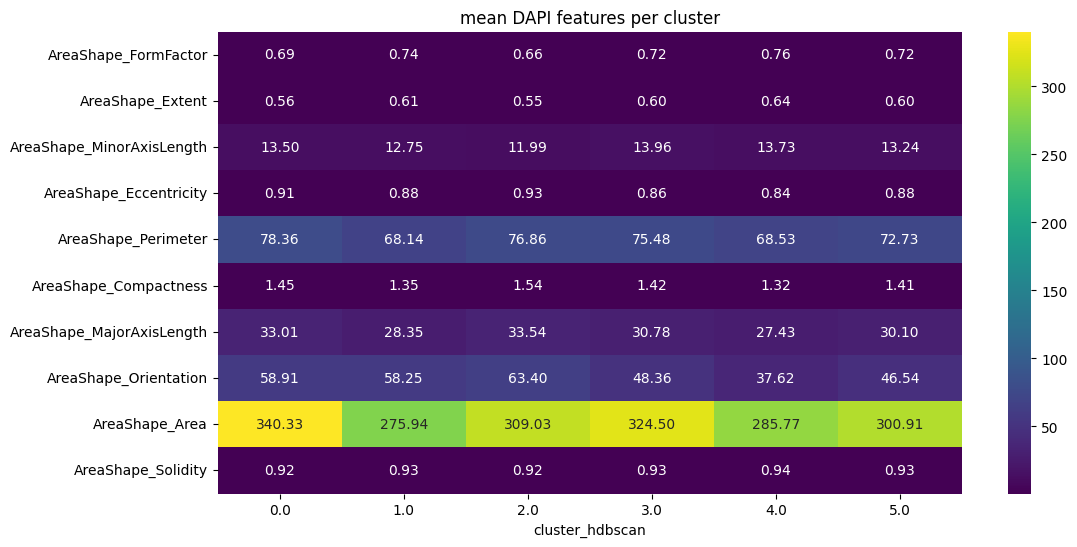

In [ ]:

df_identifyPrimaryObjects = pd.read_csv("datasets/MyExpt_IdentifyPrimaryObjects.csv")
df_Phalloidin_segmented = pd.read_csv("datasets/MyExpt_Phalloidin_segmented.csv")
df_YAP_segmented = pd.read_csv("datasets/MyExpt_YAP_segmented.csv")

colums = ['ObjectNumber', 'Metadata_ObjNumber'] + feats

cluster_map = SD_scaled[["ImageNumber", "ObjectNumber", "cluster_hdbscan"]]

def add_cluster_to_cp(cp_df, cluster_map):
    return cp_df.merge(
        cluster_map,
        left_on=["Metadata_ObjNumber", "ObjectNumber"],
        right_on=["ImageNumber", "ObjectNumber"],
        how="left"
    )  # avoid duplicate

df_identifyPrimaryObjects = add_cluster_to_cp(df_identifyPrimaryObjects, cluster_map)
df_Phalloidin_segmented = add_cluster_to_cp(df_Phalloidin_segmented, cluster_map)
df_YAP_segmented = add_cluster_to_cp(df_YAP_segmented, cluster_map)

df_identifyPrimaryObjects["cluster_hdbscan"]



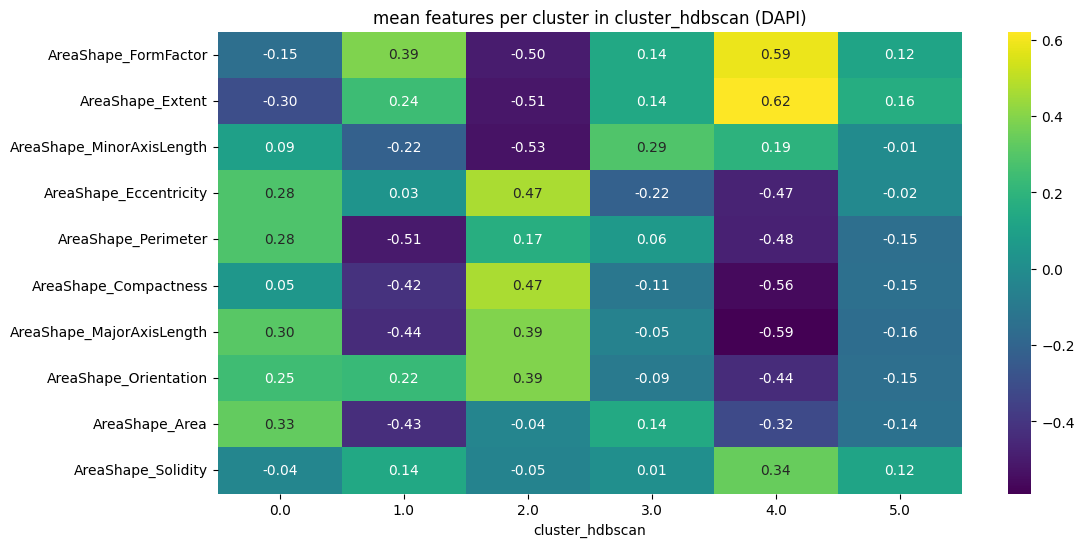

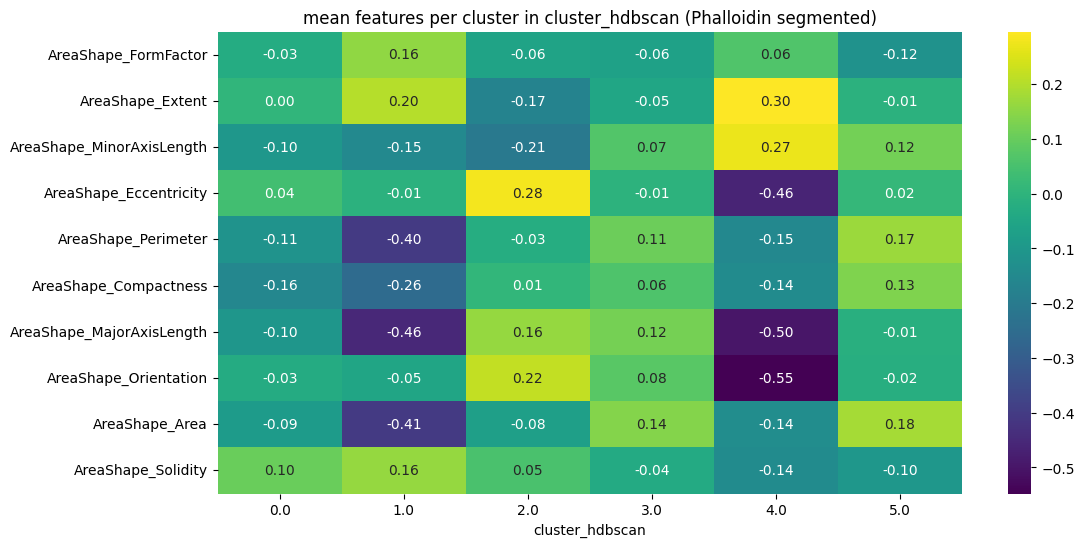

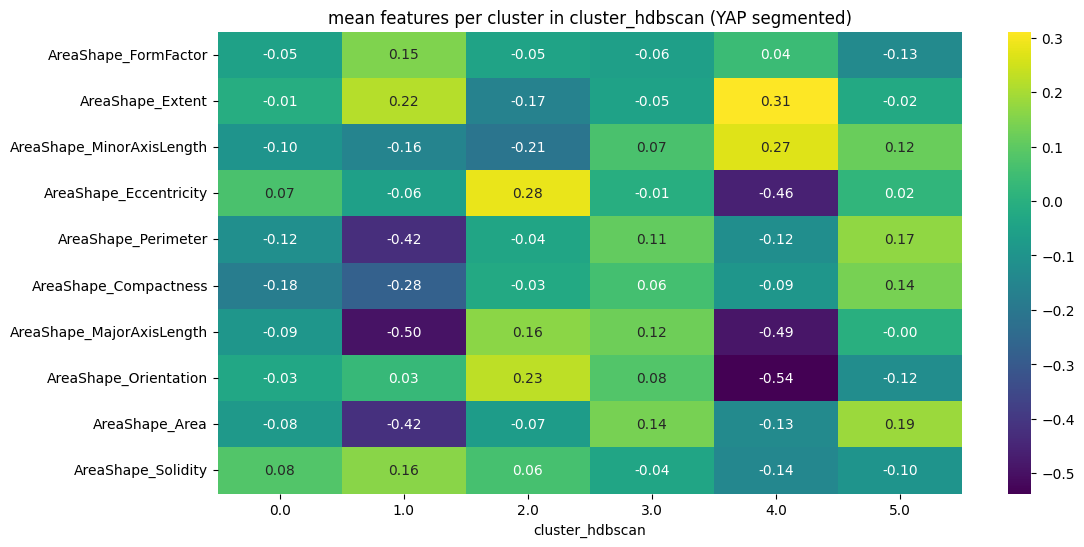

DAPI cluster counts:
cluster_hdbscan
3.0    177
2.0    110
5.0     47
1.0     36
4.0     26
0.0     24
Name: count, dtype: int64

Phalloidin segmented cluster counts:
cluster_hdbscan
3.0    177
2.0    110
5.0     47
1.0     36
4.0     26
0.0     24
Name: count, dtype: int64

YAP segmented cluster counts:
cluster_hdbscan
3.0    177
2.0    110
5.0     47
1.0     36
4.0     26
0.0     24
Name: count, dtype: int64


In [287]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_identifyPrimaryObjects[feats])

Scaled_CP_DAPI = df_identifyPrimaryObjects.copy()
Scaled_CP_DAPI[feats] = scaled

plot_metadata_heatmap(
    Scaled_CP_DAPI,
    feats,                # your list of metadata/morphology features
    "cluster_hdbscan",
    title="DAPI"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_Phalloidin_segmented[feats])

Scaled_CP_ACTIN = df_Phalloidin_segmented.copy()
Scaled_CP_ACTIN[feats] = scaled

plot_metadata_heatmap(
    Scaled_CP_ACTIN,
    feats,                # your list of metadata/morphology features
    "cluster_hdbscan",
    title="Phalloidin segmented"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_YAP_segmented[feats])

Scaled_CP_YAP = df_YAP_segmented.copy()
Scaled_CP_YAP[feats] = scaled

plot_metadata_heatmap(
    Scaled_CP_YAP,
    feats,                # your list of metadata/morphology features
    "cluster_hdbscan",
    title="YAP segmented"
)

#counts per cluster
print("DAPI cluster counts:")
print(df_identifyPrimaryObjects["cluster_hdbscan"].value_counts())
print("\nPhalloidin segmented cluster counts:")
print(df_Phalloidin_segmented["cluster_hdbscan"].value_counts())
print("\nYAP segmented cluster counts:")
print(df_YAP_segmented["cluster_hdbscan"].value_counts())